# Understanding and using `slicersim.scene.Scene`
This notebook explains what a `slicersim.scene.Scene` object is, how to create one, and how to customize it.

## 1. What is a `Scene`?
A `Scene` in `slicersim` represents what the telescope is observing. It is composed of up to three elements:
- **target**: A point source, like a supernova or a standard star.
- **background**: A uniform background, like the zodiacal light.
- **host**: A structured background, like the host galaxy of a supernova (not yet implemented).

## 2. Creating a `Scene` from a configuration dictionary

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim
from slicersim.scene.scene import Scene
from slicersim.scene.pointsource import get_snia_pointsource
from slicersim import iotools
from slicersim.profiles import get_profilemodel
from slicersim.scene.extendedsource import (ExtendedSource,
                                            get_host_extendedsource,
                                            get_elliptical_flux,
                                            elliptical_template_flux,
                                            get_flat_flux)


from sncosmo import Spectrum
from matplotlib import pyplot as plt

In [19]:
lbda = np.linspace(3500, 18000, 2000)

flux = get_elliptical_flux(lbda, mag=21.5, band="sdssr")
# flat AB spectrum has the same magnitude in every band
flux = get_flat_flux(lbda, mag=23.)


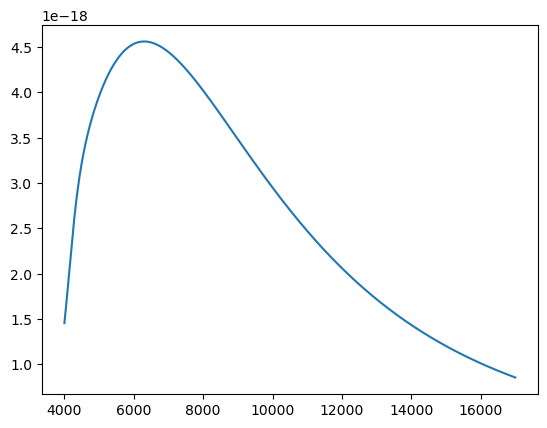

In [23]:
HostConfig = get_host_extendedsource(spectrum="elliptical",
                                     index=2., r_eff=0.7, ellip=0.3,
                                     mag=21., position=[1, 2])
host = ExtendedSource.from_config(HostConfig)


lbda = np.linspace(4000, 17000, 500)
_, spec = host.get_spectrum(lbda)


# from a user-provided spectrum
lbda_ref = np.linspace(3000, 20000, 1000)
host2 = ExtendedSource.from_config({"model_func": get_elliptical_flux, "mag": 22., "band": "sdssr"})

#host2 = ExtendedSource.from_config({"source": (lbda_ref, np.ones_like(lbda_ref) * 1e-16),
#                                    "mag": 22., "band": "sdssr"})
_, spec2 = host2.get_spectrum(lbda)
plt.plot(lbda, spec2)

In [25]:
config = {
    'host': HostConfig,
    'point_source': get_snia_pointsource(model='salt', redshift=0.5, position=(0,0)),
    'background': {'name': 'zodi', 'model': 'Aldering01.BB5800'}
}
lbda = np.linspace(4000, 17000, 1000)

In [26]:
scene = Scene.from_config(config, lbda=lbda)

In [30]:
print(scene.background)
print(scene.host)
print(dir(scene))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_background', '_host', '_lbda', '_pointsource', '_scene_meta', 'background', 'from_config', 'get_element_spectrum', 'get_stacked_spectra', 'has_element', 'host', 'meta', 'mutable_parameters', 'plot_background', 'plot_pointsource', 'pointsource', 'pointsource_position', 'update']


AttributeError: 'Scene' object has no attribute 'lbda'

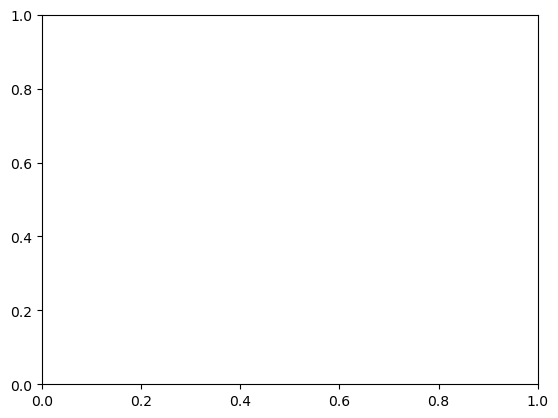

In [29]:
fig, ax = plt.subplots()
ax.plot(scene.lbda, scene.target.get_spectrum(lbda=scene.lbda)[1], label='Target')
ax.plot(scene.lbda, scene.background.get_spectrum(lbda=scene.lbda)[1], label='Background')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/A]')
ax.legend()
plt.show()

## 3. Creating a `Scene` manually

In [ ]:
from slicersim.scene.pointsource import PointSource, get_saltmodel_flux
from slicersim.scene.background import Background, zodiacal_spectrum

In [ ]:
target = PointSource(model_func=get_saltmodel_flux, 
                     position=(0,0), 
                     meta={'redshift': 0.5, 'phase': 0})

background = Background(model_func=zodiacal_spectrum, 
                        meta={'model': 'Aldering01.BB5800'})

In [ ]:
scene_manual = Scene(target=target, background=background, lbda=lbda)

In [ ]:
fig, ax = plt.subplots()
ax.plot(scene_manual.lbda, scene_manual.target.get_spectrum(lbda=scene_manual.lbda)[1], label='Target')
ax.plot(scene_manual.lbda, scene_manual.background.get_spectrum(lbda=scene_manual.lbda)[1], label='Background')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/A]')
ax.legend()
plt.show()

## 4. Creating a custom `PointSource` from a spectrum

In [ ]:
# Create a dummy spectrum
lbda_custom = np.linspace(3000, 9000, 500)
flux_custom = np.exp(-((lbda_custom - 6000) / 100)**2)

In [ ]:
custom_target = PointSource.from_spectrum(lbda_custom, flux_custom, mag=20, band='bessellb', position=(0,0))

In [ ]:
scene_custom = Scene(target=custom_target, lbda=lbda)

In [ ]:
fig, ax = plt.subplots()
ax.plot(scene_custom.lbda, scene_custom.target.get_spectrum(lbda=scene_custom.lbda)[1], label='Custom Target')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux')
ax.legend()
plt.show()

## 5. Updating `Scene` parameters

In [ ]:
lbda_plot, flux_before = scene.target.get_spectrum(lbda=scene.lbda, phase=0)

In [ ]:
scene.update(target__phase=10)

In [ ]:
lbda_plot, flux_after = scene.target.get_spectrum(lbda=scene.lbda)

In [ ]:
fig, ax = plt.subplots()
ax.plot(lbda_plot, flux_before, label='Phase 0')
ax.plot(lbda_plot, flux_after, label='Phase 10')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux')
ax.legend()
plt.show()